# Procesamiento Digital de Señales y Series Temporales
## Análisis de la acción YPF (2018–2025)

**Materia:** Procesamiento Digital de Señales  
**Carrera:** Licenciatura en Ciencias de la Computación  
**Dataset:** Cotización histórica de YPF (NYSE: YPF) — obtenido via `yfinance` (yfinance es una librería de Python que permite descargar datos financieros de forma sencilla desde Yahoo Finance.)

---

## 1. Introducción

### ¿Qué es YPF?

YPF S.A. (Yacimientos Petrolíferos Fiscales) es la empresa de energía más grande de Argentina. Fundada en 1922, opera en la exploración, producción, refinación y comercialización de petróleo, gas y derivados. Su acción cotiza en la Bolsa de Nueva York (NYSE) bajo el ticker `YPF` y en la Bolsa de Comercio de Buenos Aires (BYMA) bajo el ticker `YPFD`. Para este trabajo vamos a usar la acción `YPF` del NYSE.

### ¿Por qué es interesante analizar esta acción?

El período 2018–2025 incluye eventos que generan disrupciones claras en la serie: la crisis cambiaria argentina de 2018, la pandemia de COVID-19 (2020), la reactivación post-pandemia y el cambio de gobierno en 2023. Esta riqueza de regímenes distintos hace que el dataset sea útil para demostrar herramientas de análisis de señales y modelos de forecasting en condiciones no triviales.

### La dualidad: señal discreta vs. serie temporal

Este trabajo aborda el precio de cierre de YPF desde dos perspectivas complementarias:

- **Como señal discreta (DSP):** el precio es una secuencia muestreada a intervalos regulares (días hábiles). Aplicamos filtros de paso bajo (medias móviles) y la Transformada Rápida de Fourier (FFT) para estudiar componentes de frecuencia, ruido y tendencia.
- **Como serie temporal:** la secuencia tiene dependencia temporal (autocorrelación). Estudiamos su estacionariedad y aplicamos modelos de forecasting (SARIMA y LSTM) para predecir comportamientos futuros.

### Objetivos

1. Aplicar filtros SMA y EMA para separar tendencia del ruido.
2. Analizar el espectro de frecuencias con FFT para detectar ciclos.
3. Evaluar la estacionariedad con el test ADF.
4. Entrenar y comparar SARIMA y LSTM.
5. Interpretar los resultados en ambos marcos conceptuales.

#### Requerimientos

In [1]:
#Instalar requirements
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


#### Bibliotecas utilizadas
Para realizar el análisis se utilizaron bibliotecas de Python ampliamente utilizadas en ciencia de datos y aprendizaje automático. NumPy y Pandas se emplearon para el manejo y procesamiento de los datos, Matplotlib para la generación de gráficos, yfinance para obtener las cotizaciones históricas de YPF, SciPy para algunas operaciones de procesamiento de señales, Statsmodels para los modelos estadísticos, TensorFlow para la implementación de la red LSTM y Scikit-learn para el preprocesamiento y evaluación de los modelos.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from scipy.fft import fft, fftfreq

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print(f"TensorFlow {tf.__version__} | Pandas {pd.__version__} | NumPy {np.__version__}")

TensorFlow 2.21.0 | Pandas 3.0.3 | NumPy 2.4.6


### 1.1 Descarga y exploración inicial

Bajamos el dataset desde Yahoo Finance y vemos algunas lineas

In [7]:
df_raw = yf.download("YPF", start="2018-01-01", end="2025-01-01", auto_adjust=True)

# yfinance puede devolver columnas con MultiIndex dependiendo de la versión
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df = df_raw[['Close']].copy()
df.index = pd.to_datetime(df.index)
df.index.name = 'Date'
print(df.head())
print("\n")
print(df.tail())



[*********************100%***********************]  1 of 1 completed

Price           Close
Date                 
2018-01-02  23.311459
2018-01-03  23.272017
2018-01-04  22.966326
2018-01-05  22.690218
2018-01-08  23.419931


Price           Close
Date                 
2024-12-24  42.790001
2024-12-26  43.060001
2024-12-27  42.639999
2024-12-30  42.369999
2024-12-31  42.509998


Veamos algunas metricas estadisticas simples para entender el dataset usando un describe

In [8]:
print(f"Registros: {len(df)} | Desde: {df.index.min().date()} | Hasta: {df.index.max().date()}")
print(f"Valores nulos: {df['Close'].isna().sum()}")
print()
print(df.describe().round(2))

Registros: 1761 | Desde: 2018-01-02 | Hasta: 2024-12-31
Valores nulos: 0

Price    Close
count  1761.00
mean     11.78
std       7.50
min       2.57
25%       4.77
50%      10.81
75%      16.04
max      44.88


Precios de cierre historicos YPF (2018 - 2025)

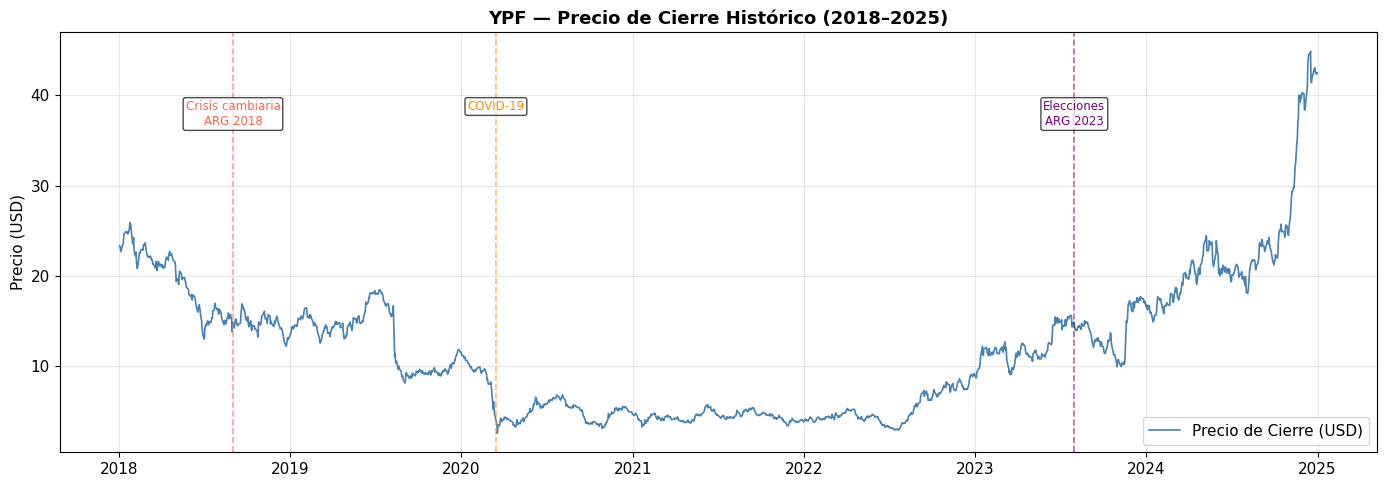

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.2, label='Precio de Cierre (USD)')

eventos = {
    '2018-09-01': ('Crisis cambiaria\nARG 2018', 'tomato'),
    '2020-03-15': ('COVID-19', 'darkorange'),
    '2023-08-01': ('Elecciones\nARG 2023', 'purple'),
}
for fecha, (texto, color) in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color=color, linestyle='--', alpha=0.6, linewidth=1.2)
    ax.text(pd.Timestamp(fecha), df['Close'].max() * 0.88, texto,
            color=color, fontsize=8.5, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('YPF — Precio de Cierre Histórico (2018–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

La serie muestra una caída pronunciada en 2018 (crisis cambiaria), un piso en marzo de 2020 (inicio de la pandemia) y una recuperación posterior con alta volatilidad. La forma de la curva ya anticipa que la serie no será estacionaria.

---
## 2. Procesamiento de Señales

El precio de cierre de la acción puede modelarse como una señal discreta, ya que se observa únicamente en instantes separados de tiempo (días hábiles de mercado). Cada observación constituye una muestra de la señal, formando una secuencia temporal sobre la cual pueden aplicarse técnicas de procesamiento digital de señales.

Desde esta perspectiva, la señal tiene dos componentes superpuestos:

- **Tendencia** (baja frecuencia): el movimiento lento de mediano y largo plazo.
- **Ruido** (alta frecuencia): las fluctuaciones diarias que no aportan información sobre la tendencia.

El objetivo de esta sección es separar ambas componentes usando filtros y luego analizar el contenido frecuencial de la señal.

### 2.1 Suavizado: SMA y EMA como filtros de paso bajo

Las medias móviles son **filtros de paso bajo**: atenúan las componentes de alta frecuencia (ruido de corto plazo) y preservan las de baja frecuencia (tendencia). Son el equivalente financiero de un filtro de suavizado aplicado a una señal de audio o imagen.

**SMA (Simple Moving Average):** promedio aritmético uniforme de los últimos $n$ valores.

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} x_{t-i}$$

**EMA (Exponential Moving Average):** pondera exponencialmente más los valores recientes. Tiene menor retraso (*lag*) que la SMA ante cambios de tendencia debido a que asigna mayor peso a las observaciones recientes.

$$\text{EMA}_t = \alpha \cdot x_t + (1-\alpha) \cdot \text{EMA}_{t-1}, \quad \alpha = \frac{2}{n+1}$$

Usaremos ventanas de **20 días** (1 mes bursatil o 20 ruedas de mercado) y **60 días** (1 trimestre o 3 ruedas de 20 dias).

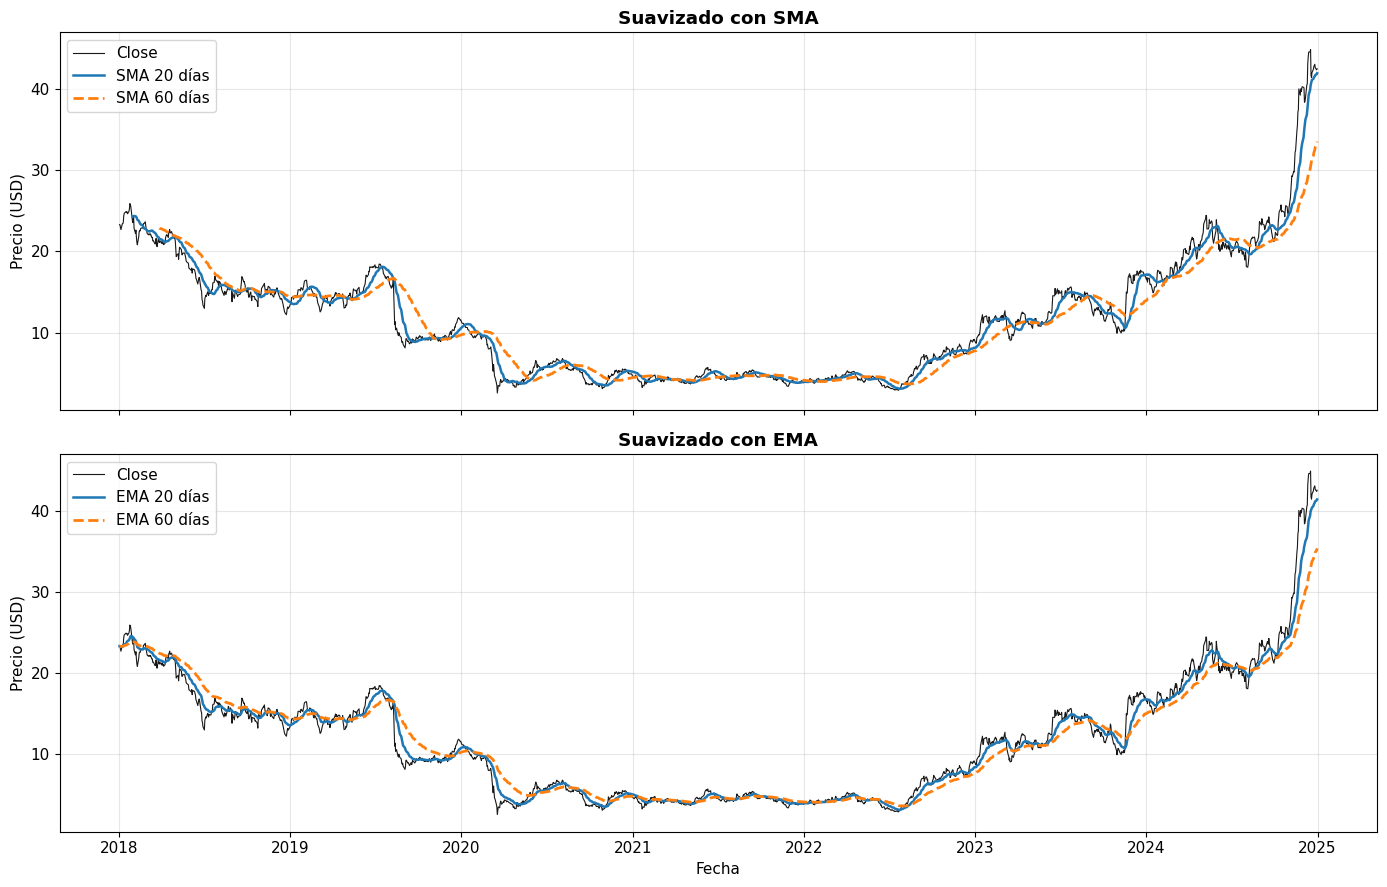

In [15]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_60'] = df['Close'].rolling(window=60).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_60'] = df['Close'].ewm(span=60, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, (col20, col60, titulo) in zip(axes, [
    ('SMA_20', 'SMA_60', 'SMA'),
    ('EMA_20', 'EMA_60', 'EMA')
]):
    ax.plot(df.index, df['Close'], color='black', linewidth=0.8, alpha=0.9, label='Close')
    ax.plot(df.index, df[col20], linewidth=1.8, label=f'{titulo} 20 días')
    ax.plot(df.index, df[col60], linewidth=2.0, linestyle='--', label=f'{titulo} 60 días')
    ax.set_title(f'Suavizado con {titulo}', fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.legend()

axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

Los resultados muestran que tanto SMA como EMA actúan como filtros de suavizado sobre la serie de precios. Las ventanas de 60 días producen una mayor atenuación de las fluctuaciones de corto plazo que las de 20 días, a costa de introducir un mayor retraso respecto a la señal original. Asimismo, las EMA siguen más de cerca los movimientos del precio que las SMA equivalentes, debido a la mayor ponderación asignada a las observaciones recientes. En todos los casos, los filtros permiten resaltar la tendencia general de la acción y facilitar su análisis visual.
En particular la EMA 60 muestra una tendencia alcista fuerte en los últimos años.

### Cruce de EMAs

Estos cruces permiten visualizar posibles cambios de tendencia en la serie de precios. Debido a que la EMA de corto plazo es más sensible a los cambios recientes, los cruces con la EMA de largo plazo pueden actuar como indicadores de cambio en la dirección general de la tendencia.

Se identifican señales alcistas cuando la EMA de 20 días cruza por encima de la EMA de 60 días y señales bajistas cuando ocurre el cruce inverso.

Mientras no se produzca un nuevo cruce entre las medias móviles, se considera que la tendencia previamente identificada permanece vigente. De esta manera, los cruces actúan como posibles puntos de cambio de tendencia, mientras que los períodos entre cruces representan fases de continuidad de la tendencia dominante (observar 2024 a 2025).

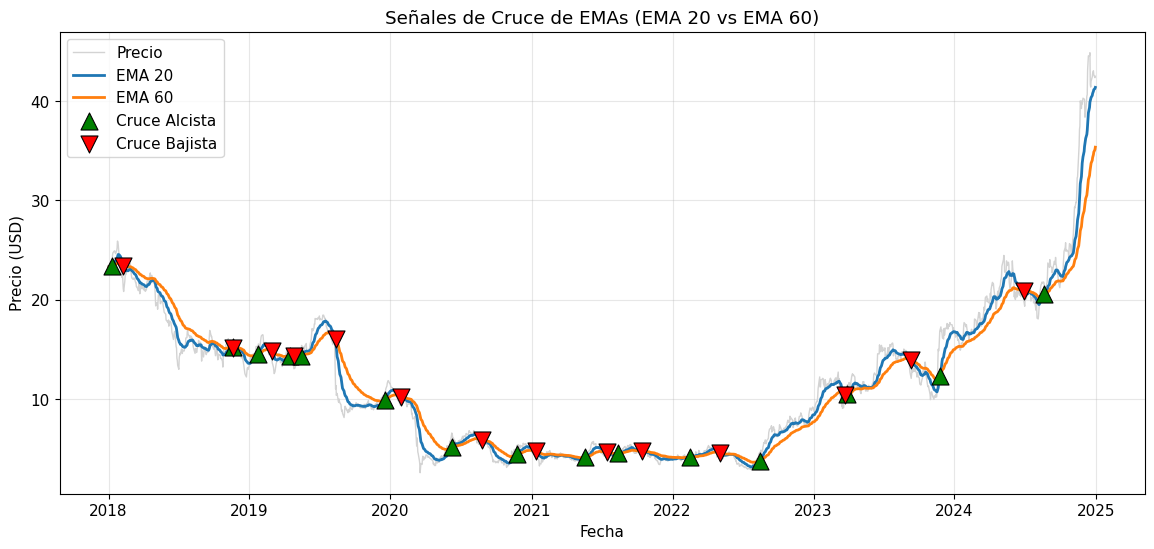

In [19]:
# Detectar cruces
df['Signal'] = np.where(df['EMA_20'] > df['EMA_60'], 1, 0)
df['Crossover'] = df['Signal'].diff()

bullish = df[df['Crossover'] == 1]
bearish = df[df['Crossover'] == -1]

# Graficar
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], color='lightgray', linewidth=1, label='Precio')
plt.plot(df.index, df['EMA_20'], linewidth=2, label='EMA 20')
plt.plot(df.index, df['EMA_60'], linewidth=2, label='EMA 60')

plt.scatter(
    bullish.index,
    bullish['EMA_20'],
    marker='^',
    s=150,
    color='green',
    edgecolors='black',
    linewidths=0.8,
    zorder=10,
    label='Cruce Alcista'
)

plt.scatter(
    bearish.index,
    bearish['EMA_20'],
    marker='v',
    s=150,
    color='red',
    edgecolors='black',
    linewidths=0.8,
    zorder=10,
    label='Cruce Bajista'
)

plt.title('Señales de Cruce de EMAs (EMA 20 vs EMA 60)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Al restar la SMA de la señal original se obtiene una componente residual que representa las fluctuaciones de corto plazo no capturadas por la tendencia. El análisis de esta componente permite identificar períodos de mayor volatilidad y cuantificar qué tan alejado se encuentra el precio respecto de su comportamiento promedio reciente.

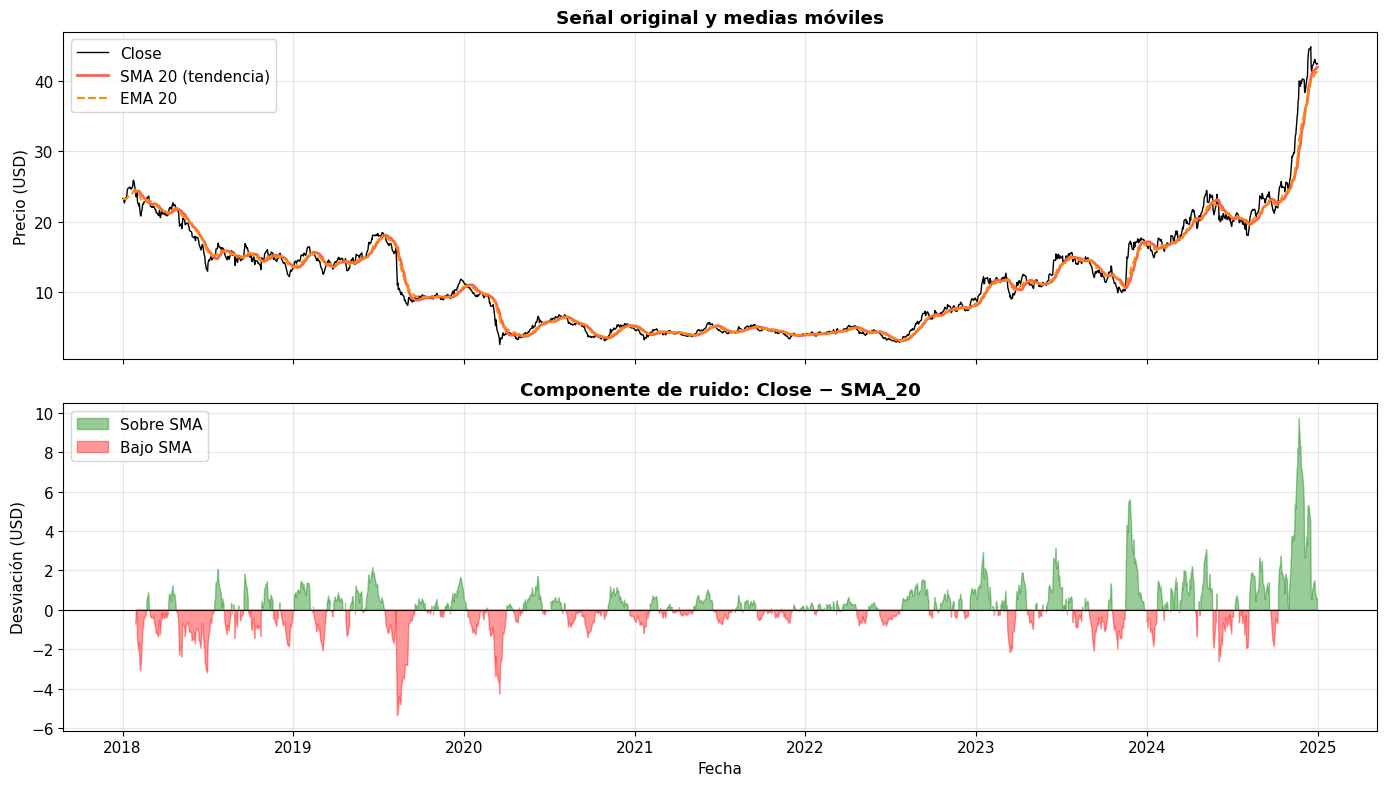

In [16]:
 # La diferencia entre la señal original y la SMA_20 es la componente de ruido
df['Ruido'] = df['Close'] - df['SMA_20']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Close'], color='black', linewidth=1.0, label='Close')
axes[0].plot(df.index, df['SMA_20'], color='tomato', linewidth=2.0, label='SMA 20 (tendencia)')
axes[0].plot(df.index, df['EMA_20'], color='darkorange', linewidth=1.5, linestyle='--', label='EMA 20')
axes[0].set_title('Señal original y medias móviles', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend()

axes[1].fill_between(df.index, df['Ruido'], 0,
                     where=(df['Ruido'] >= 0), color='green', alpha=0.4, label='Sobre SMA')
axes[1].fill_between(df.index, df['Ruido'], 0,
                     where=(df['Ruido'] < 0),  color='red',   alpha=0.4, label='Bajo SMA')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Componente de ruido: Close − SMA_20', fontweight='bold')
axes[1].set_ylabel('Desviación (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observaciones:**

Se observa que la SMA y la EMA permiten aislar la tendencia general de la acción, mientras que la diferencia entre el precio y la SMA refleja las fluctuaciones de corto plazo. Las desviaciones más grandes se concentran en períodos de alta volatilidad, donde el precio se aleja significativamente de la tendencia estimada por la media móvil.

---
## 3. Análisis Temporal

En esta sección cambiamos de perspectiva: ya no analizamos el precio como una señal genérica, sino como una **serie temporal** con estructura de autocorrelación. Este análisis es un prerrequisito para cualquier modelo de forecasting.

### 3.1 Estacionariedad y Test ADF

Una serie temporal es **estacionaria** si sus propiedades estadísticas, como la media, la varianza y la autocovarianza, permanecen aproximadamente constantes a lo largo del tiempo. Intuitivamente, una serie estacionaria fluctúa alrededor de un mismo nivel sin presentar tendencias persistentes ni cambios sistemáticos en su variabilidad.

La estacionariedad es un requisito importante para muchos modelos clásicos de series temporales, como ARIMA y SARIMA, ya que estos modelos asumen que la estructura estadística de la serie no cambia con el tiempo. Cuando una serie presenta tendencia o cambios en su comportamiento, suele ser necesario transformarla antes de aplicar estos modelos.

Para evaluar esta propiedad se utiliza el **test Augmented Dickey-Fuller (ADF)**, que permite detectar la presencia de una **raíz unitaria**. Una raíz unitaria indica que los efectos de perturbaciones aleatorias persisten en el tiempo y no se disipan. Como consecuencia, la serie no presenta una media constante alrededor de la cual oscile y se considera no estacionaria.

El test plantea las siguientes hipótesis:

- $H_0$: la serie posee una raíz unitaria (no es estacionaria).
- $H_1$: la serie es estacionaria.

Se rechaza $H_0$ cuando el estadístico ADF es menor que el valor crítico correspondiente o, de forma equivalente, cuando el p-valor es inferior a 0.05.

In [17]:
def mostrar_adf(serie, nombre):
    """Ejecuta el test ADF y muestra los resultados de forma legible."""
    res = adfuller(serie.dropna(), autolag='AIC')
    print(f"  Test ADF — {nombre}")
    print(f"  Estadístico : {res[0]:.4f}")
    print(f"  p-valor     : {res[1]:.6f}")
    print(f"  Lags usados : {res[2]}")
    for nivel, val in res[4].items():
        marca = " ← estadístico más negativo ✓" if res[0] < val else ""
        print(f"  Valor crítico {nivel}: {val:.4f}{marca}")
    if res[1] < 0.05:
        print("  → Conclusión: p < 0.05. Se RECHAZA H₀. La serie ES estacionaria.")
    else:
        print("  → Conclusión: p ≥ 0.05. NO se rechaza H₀. La serie NO es estacionaria.")
    print()
    return res

serie_original = df['Close'].dropna()

print("=" * 55)
res_original = mostrar_adf(serie_original, "Precio de Cierre (nivel)")

  Test ADF — Precio de Cierre (nivel)
  Estadístico : 1.3266
  p-valor     : 0.996754
  Lags usados : 5
  Valor crítico 1%: -3.4341
  Valor crítico 5%: -2.8632
  Valor crítico 10%: -2.5676
  → Conclusión: p ≥ 0.05. NO se rechaza H₀. La serie NO es estacionaria.



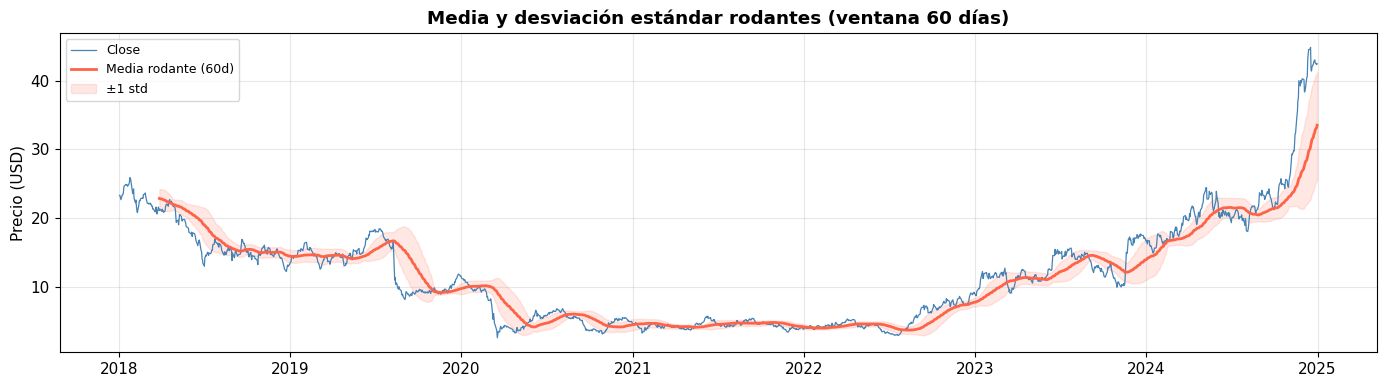

In [20]:
# Visualización de media y varianza rodantes para confirmar visualmente
media_rodante = serie_original.rolling(60).mean()
std_rodante   = serie_original.rolling(60).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_original.index, serie_original.values, color='steelblue', linewidth=0.9, label='Close')
ax.plot(serie_original.index, media_rodante, color='tomato', linewidth=2.0, label='Media rodante (60d)')
ax.fill_between(serie_original.index,
                media_rodante - std_rodante, media_rodante + std_rodante,
                alpha=0.15, color='tomato', label='±1 std')
ax.set_title('Media y desviación estándar rodantes (ventana 60 días)', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La Figura muestra la media rodante y la desviación estándar calculadas sobre ventanas móviles de 60 días. La media rodante representa el promedio de los últimos 60 valores de la serie en cada instante y permite observar cómo evoluciona su nivel promedio a lo largo del tiempo. Se observa que tanto la media como la variabilidad cambian significativamente durante el período analizado, lo que constituye evidencia visual de que la serie no es estacionaria y coincide con los resultados obtenidos mediante el test ADF.

### Diferenciación de primer orden

Dado que la serie de precios no es estacionaria, se aplica una **diferenciación de primer orden**, definida como:

$$
\Delta P_t = P_t - P_{t-1}
$$

Esta transformación calcula la diferencia entre el precio actual y el del período anterior. Se denomina *de primer orden* porque la diferencia se calcula una sola vez utilizando observaciones consecutivas. Si la serie siguiera sin ser estacionaria, podría aplicarse una segunda diferenciación sobre la serie resultante.

Al realizar esta operación, la información sobre la tendencia de largo plazo se reduce significativamente y la serie pasa a representar las variaciones diarias del precio en lugar de sus valores absolutos. Como consecuencia, suele obtenerse una serie que oscila alrededor de un nivel aproximadamente constante, condición necesaria para aplicar modelos como ARIMA o SARIMA.

  Test ADF — Primera diferencia (d=1)
  Estadístico : -18.2285
  p-valor     : 0.000000
  Lags usados : 4
  Valor crítico 1%: -3.4341 ← estadístico más negativo ✓
  Valor crítico 5%: -2.8632 ← estadístico más negativo ✓
  Valor crítico 10%: -2.5676 ← estadístico más negativo ✓
  → Conclusión: p < 0.05. Se RECHAZA H₀. La serie ES estacionaria.



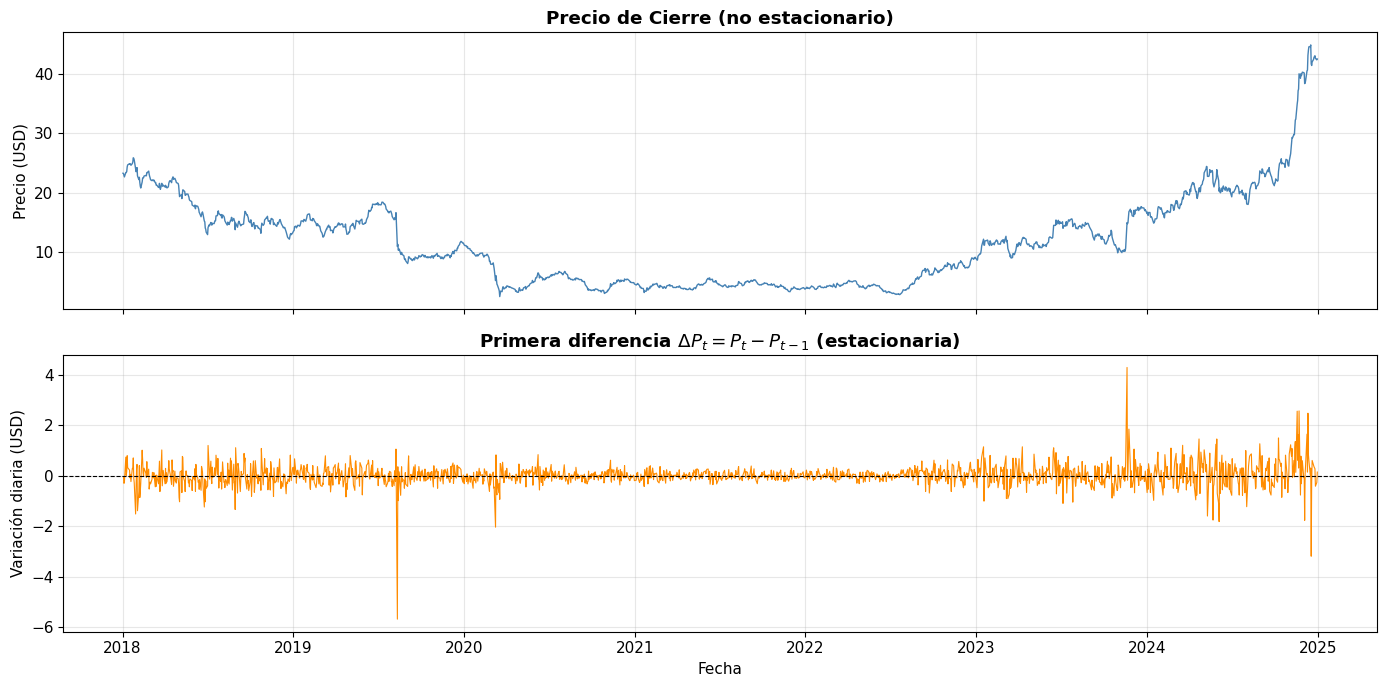

In [23]:
df['Close_diff1'] = df['Close'].diff(1)
serie_diff1 = df['Close_diff1'].dropna()

print("=" * 55)
res_diff = mostrar_adf(serie_diff1, "Primera diferencia (d=1)")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(serie_original.index, serie_original.values, color='steelblue', linewidth=1.0)
axes[0].set_title('Precio de Cierre (no estacionario)', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')

axes[1].plot(serie_diff1.index, serie_diff1.values, color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(r'Primera diferencia $\Delta P_t = P_t - P_{t-1}$ (estacionaria)', fontweight='bold')
axes[1].set_ylabel('Variación diaria (USD)')
axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

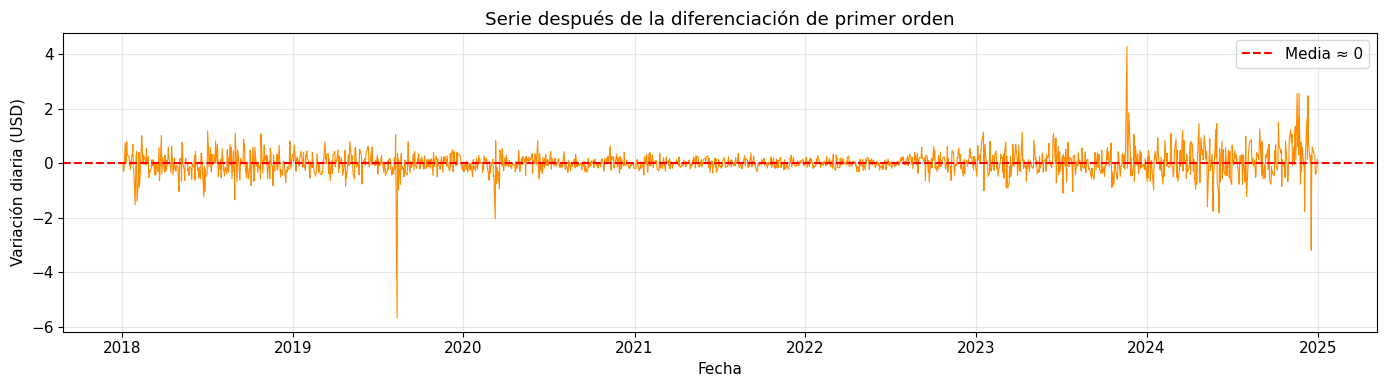

In [25]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(serie_diff1.index, serie_diff1.values,
        color='darkorange', linewidth=0.8)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5,
           label='Media ≈ 0')

ax.set_title('Serie después de la diferenciación de primer orden')
ax.set_ylabel('Variación diaria (USD)')
ax.set_xlabel('Fecha')
ax.legend()

plt.tight_layout()
plt.show()

Tras aplicar la diferenciación de primer orden, la serie deja de presentar una tendencia evidente y pasa a oscilar alrededor de cero. Este comportamiento sugiere una mejora significativa respecto de la serie original en términos de estacionariedad. La conclusión se confirma mediante el test ADF, que rechaza la hipótesis nula de presencia de raíz unitaria (p < 0.05).

**La serie diferenciada es simplemente un gráfico de las diferencias entre días consecutivos.**

### 3.2 División temporal y preparación para Forecasting

Dividimos la serie en **80% entrenamiento / 20% prueba**, respetando el orden cronológico. Una división aleatoria filtrarías información del futuro hacia el pasado (*data leakage*), invalidando la evaluación.

Ambos modelos trabajarán sobre el **precio de cierre sin diferenciar**:
- **SARIMA** incorpora internamente el parámetro $d$, que indica cuántas veces debe diferenciarse la serie para volverla estacionaria antes de ajustar el modelo. En este trabajo se utiliza $d=1$, ya que una única diferenciación fue suficiente para que la serie superara el test ADF de estacionariedad.
- **LSTM** no requiere estacionariedad, pero sí normalización de los datos.


Entrenamiento : 1408 obs  (2018-01-02 → 2023-08-07)
Test          : 353 obs  (2023-08-08 → 2024-12-31)


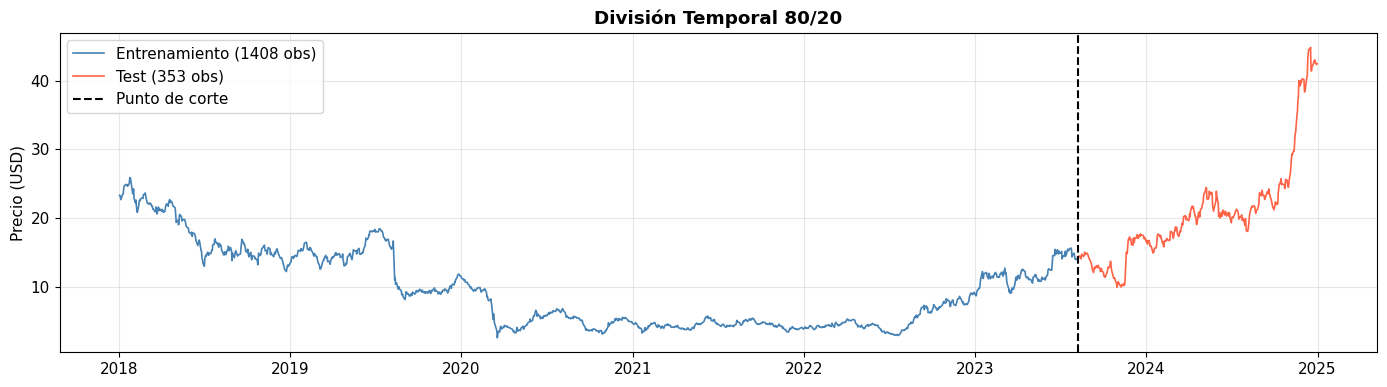

In [37]:
serie_precios = df['Close'].dropna()
split_idx     = int(len(serie_precios) * 0.80)
train_series  = serie_precios.iloc[:split_idx]
test_series   = serie_precios.iloc[split_idx:]

print(f"Entrenamiento : {len(train_series)} obs  ({train_series.index[0].date()} → {train_series.index[-1].date()})")
print(f"Test          : {len(test_series)} obs  ({test_series.index[0].date()} → {test_series.index[-1].date()})")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_series.index, train_series.values, color='steelblue', linewidth=1.2,
        label=f'Entrenamiento ({len(train_series)} obs)')
ax.plot(test_series.index,  test_series.values,  color='tomato',    linewidth=1.2,
        label=f'Test ({len(test_series)} obs)')
ax.axvline(test_series.index[0], color='black', linestyle='--', linewidth=1.5, label='Punto de corte')
ax.set_title('División Temporal 80/20', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Forecasting

Comparamos dos enfoques con filosofías distintas:

- **SARIMA**: modelo estadístico lineal clásico, basado en autocorrelaciones. Interpretable y con fundamento matemático explícito.
- **LSTM**: red neuronal recurrente capaz de aprender dependencias temporales no lineales. Menos interpretable pero más flexible.

### 4.1 Modelo SARIMA

SARIMA extiende ARIMA con un componente estacional:

$$\text{SARIMA}(p,d,q)(P,D,Q)[s]$$

donde $p, d, q$ son los órdenes autoregresivo, de integración y de media móvil, y $P, D, Q, s$ son sus equivalentes estacionales.

**Selección de parámetros:** del análisis ADF determinamos $d=1$. Para elegir $p$ y $q$ usamos los gráficos ACF y PACF sobre la serie diferenciada. La regla de lectura es:
- PACF con corte abrupto en el lag $p$ → modelo AR($p$)
- ACF con corte abrupto en el lag $q$ → modelo MA($q$)

Para el componente estacional usamos $s=5$ (semana hábil), motivado por los picos que la FFT detectó en esa frecuencia.

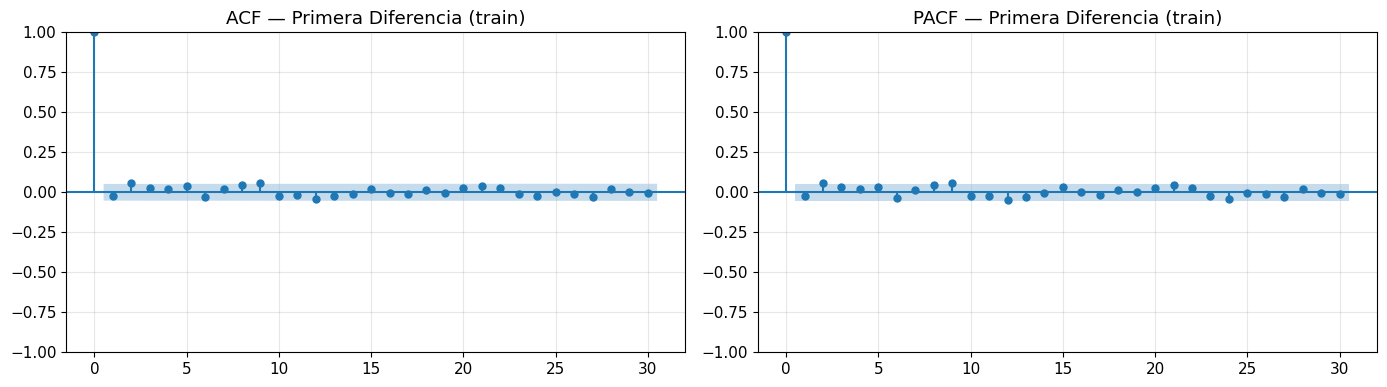

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
serie_diff_train = train_series.diff(1).dropna()

plot_acf(serie_diff_train,  lags=30, ax=axes[0], title='ACF — Primera Diferencia (train)')
plot_pacf(serie_diff_train, lags=30, ax=axes[1], title='PACF — Primera Diferencia (train)', method='ywm')

plt.tight_layout()
plt.show()

Tanto ACF como PACF muestran valores que caen rápidamente dentro de las bandas de confianza (zona azul) después del primer lag. Esto indica muy poca autocorrelación estructural en la primera diferencia, lo que justifica usar órdenes bajos: $p=1$, $q=1$.

In [39]:
print("Entrenando SARIMA(1,1,1)(1,0,0)[5]...")

modelo_sarima = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)

print(f"AIC: {resultado_sarima.aic:.2f} | BIC: {resultado_sarima.bic:.2f}")
print(resultado_sarima.summary().tables[1])

Entrenando SARIMA(1,1,1)(1,0,0)[5]...
AIC: 979.33 | BIC: 1000.31
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0882      0.520      0.170      0.865      -0.930       1.106
ma.L1         -0.1056      0.518     -0.204      0.838      -1.121       0.909
ar.S.L5        0.0369      0.022      1.698      0.090      -0.006       0.080
sigma2         0.1171      0.001     95.432      0.000       0.115       0.120


In [40]:
pred_sarima = resultado_sarima.forecast(steps=len(test_series))
pred_sarima.index = test_series.index

print("Primeras predicciones SARIMA:")
print(pred_sarima.head().round(2))

Primeras predicciones SARIMA:
Date
2023-08-08    13.94
2023-08-09    13.93
2023-08-10    13.92
2023-08-11    13.92
2023-08-14    13.92
Name: predicted_mean, dtype: float64


### 4.2 Modelo LSTM

Las redes **LSTM** (Long Short-Term Memory) son redes neuronales recurrentes con celdas de memoria y puertas de entrada, olvido y salida. Estas puertas permiten al modelo aprender qué información de pasos anteriores retener y cuál descartar, lo que las hace adecuadas para capturar dependencias de largo plazo.

**Preparación de datos:** construimos ventanas deslizantes de tamaño $w$. Para cada paso $t$, el modelo recibe $[P_{t-w}, \ldots, P_{t-1}]$ y predice $P_t$. Usamos $w=20$ días.

**Normalización:** el precio se escala al rango $[0,1]$ usando `MinMaxScaler`. Importante: el scaler se ajusta **solo** sobre el conjunto de entrenamiento para evitar filtrar información del futuro.

In [41]:
VENTANA = 20

scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
test_scaled  = scaler.transform(test_series.values.reshape(-1, 1))

def crear_secuencias(data, ventana):
    """Construye pares (X, y) con ventana deslizante."""
    X = np.array([data[i - ventana:i, 0] for i in range(ventana, len(data))])
    y = data[ventana:, 0]
    return X.reshape(len(X), ventana, 1), y

# El contexto del test se inicializa con los últimos VENTANA días del train
# para que la primera predicción tenga una ventana válida
datos_test_con_contexto = np.concatenate([train_scaled[-VENTANA:], test_scaled], axis=0)

X_train, y_train = crear_secuencias(train_scaled, VENTANA)
X_test,  y_test  = crear_secuencias(datos_test_con_contexto, VENTANA)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

X_train: (1388, 20, 1) | y_train: (1388,)
X_test:  (353, 20, 1)  | y_test:  (353,)


In [42]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

modelo_lstm = Sequential([
    LSTM(64, input_shape=(VENTANA, 1)),
    Dropout(0.2),
    Dense(1)
])
modelo_lstm.compile(optimizer='adam', loss='mean_squared_error')
modelo_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

print("\nEntrenando LSTM...")
historia = modelo_lstm.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nEpochs ejecutados: {len(historia.history['loss'])}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando LSTM...
Epoch 1/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0164 - val_loss: 0.0014
Epoch 2/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 3/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 4/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 5/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 6/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 7/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 8/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 9/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 10/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 11/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 12/80
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

**Nota sobre la arquitectura:** se removió la capa `Dense(32, activation='relu')` intermedia que estaba en la versión anterior. Esa capa no aportaba valor en un problema de regresión sobre series univariadas de esta escala: añadía parámetros entrenables sin justificación teórica y aumentaba el riesgo de sobreajuste. La arquitectura LSTM → Dropout → Dense(1) es suficiente y más honesta para el objetivo del trabajo.

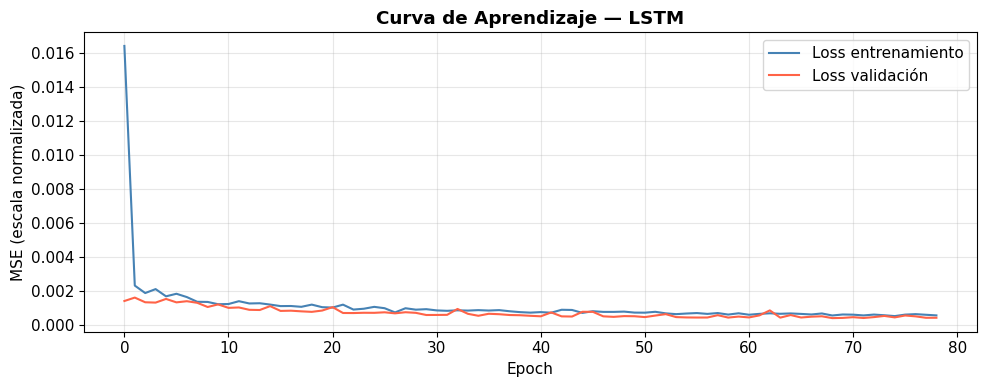

In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historia.history['loss'],     label='Loss entrenamiento', color='steelblue')
ax.plot(historia.history['val_loss'], label='Loss validación',    color='tomato')
ax.set_title('Curva de Aprendizaje — LSTM', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (escala normalizada)')
ax.legend()
plt.tight_layout()
plt.show()

Ambas curvas descienden y convergen. Si la curva de validación empezara a subir mientras la de entrenamiento sigue bajando, sería señal de sobreajuste; el EarlyStopping está configurado para detener el entrenamiento en ese caso.

In [44]:
pred_lstm_scaled = modelo_lstm.predict(X_test, verbose=0)
pred_lstm        = scaler.inverse_transform(pred_lstm_scaled).flatten()
pred_lstm_series = pd.Series(pred_lstm, index=test_series.index)

print("Primeras predicciones LSTM:")
print(pred_lstm_series.head().round(2))

Primeras predicciones LSTM:
Date
2023-08-08    13.97
2023-08-09    14.06
2023-08-10    14.18
2023-08-11    14.31
2023-08-14    14.44
dtype: float32


---
## 5. Evaluación

Evaluamos con dos métricas complementarias, ambas en USD para facilitar la interpretación:

- **RMSE:** penaliza proporcionalmente más los errores grandes. $\text{RMSE} = \sqrt{\frac{1}{n}\sum(\hat{y}_i - y_i)^2}$
- **MAE:** promedio de los errores absolutos, más robusto a valores atípicos. $\text{MAE} = \frac{1}{n}\sum|\hat{y}_i - y_i|$

Incluimos un **baseline naive** como referencia: predice siempre el último precio conocido del entrenamiento. Si un modelo no supera este baseline, su complejidad no está justificada.

In [45]:
y_real = test_series.values

rmse_sarima   = np.sqrt(mean_squared_error(y_real, pred_sarima.values))
mae_sarima    = mean_absolute_error(y_real, pred_sarima.values)

rmse_lstm     = np.sqrt(mean_squared_error(y_real, pred_lstm))
mae_lstm      = mean_absolute_error(y_real, pred_lstm)

# Baseline naive: predice siempre el último valor del conjunto de entrenamiento
baseline_pred = np.full(len(y_real), fill_value=train_series.iloc[-1])
rmse_baseline = np.sqrt(mean_squared_error(y_real, baseline_pred))
mae_baseline  = mean_absolute_error(y_real, baseline_pred)

print(f"{'Modelo':<28} {'RMSE (USD)':>12}  {'MAE (USD)':>12}")
print("-" * 55)
print(f"{'Baseline (naive)':<28} {rmse_baseline:>12.3f}  {mae_baseline:>12.3f}")
print(f"{'SARIMA(1,1,1)(1,0,0)[5]':<28} {rmse_sarima:>12.3f}  {mae_sarima:>12.3f}")
print(f"{'LSTM':<28} {rmse_lstm:>12.3f}  {mae_lstm:>12.3f}")

mejor = 'LSTM' if rmse_lstm < rmse_sarima else 'SARIMA'
print(f"\nMejor modelo por RMSE: {mejor}")

Modelo                         RMSE (USD)     MAE (USD)
-------------------------------------------------------
Baseline (naive)                   10.038         7.275
SARIMA(1,1,1)(1,0,0)[5]            10.060         7.298
LSTM                                0.883         0.641

Mejor modelo por RMSE: LSTM


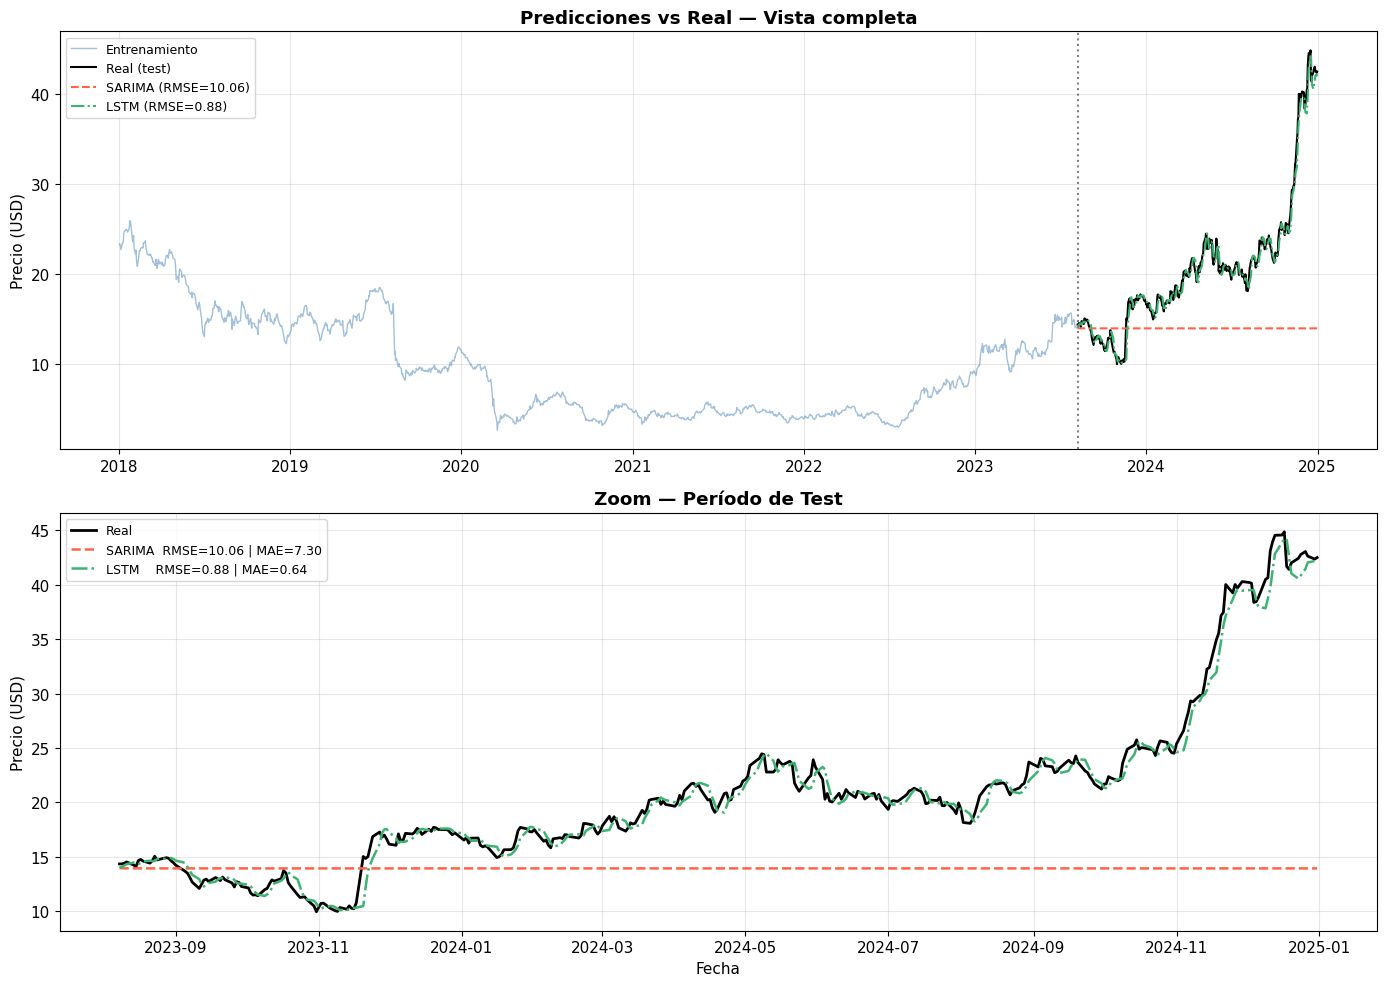

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Vista completa
axes[0].plot(train_series.index, train_series.values,
             color='steelblue', linewidth=1.0, alpha=0.5, label='Entrenamiento')
axes[0].plot(test_series.index,  test_series.values,
             color='black',     linewidth=1.5, label='Real (test)')
axes[0].plot(pred_sarima.index,  pred_sarima.values,
             color='tomato',    linewidth=1.5, linestyle='--',
             label=f'SARIMA (RMSE={rmse_sarima:.2f})')
axes[0].plot(pred_lstm_series.index, pred_lstm_series.values,
             color='mediumseagreen', linewidth=1.5, linestyle='-.',
             label=f'LSTM (RMSE={rmse_lstm:.2f})')
axes[0].axvline(test_series.index[0], color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title('Predicciones vs Real — Vista completa', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend(fontsize=9)

# Zoom en el período de test
axes[1].plot(test_series.index, test_series.values,
             color='black', linewidth=2.0, label='Real')
axes[1].plot(pred_sarima.index, pred_sarima.values,
             color='tomato', linewidth=1.8, linestyle='--',
             label=f'SARIMA  RMSE={rmse_sarima:.2f} | MAE={mae_sarima:.2f}')
axes[1].plot(pred_lstm_series.index, pred_lstm_series.values,
             color='mediumseagreen', linewidth=1.8, linestyle='-.',
             label=f'LSTM    RMSE={rmse_lstm:.2f} | MAE={mae_lstm:.2f}')
axes[1].set_title('Zoom — Período de Test', fontweight='bold')
axes[1].set_ylabel('Precio (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

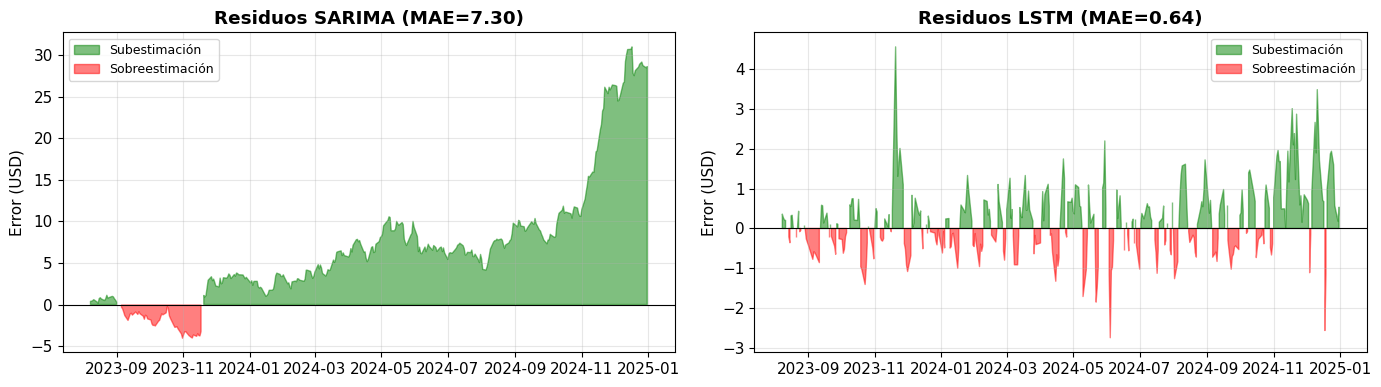

In [47]:
# Residuos
error_sarima = y_real - pred_sarima.values
error_lstm   = y_real - pred_lstm

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, error, titulo, color in zip(
    axes,
    [error_sarima, error_lstm],
    [f'Residuos SARIMA (MAE={mae_sarima:.2f})', f'Residuos LSTM (MAE={mae_lstm:.2f})'],
    ['tomato', 'mediumseagreen']
):
    ax.fill_between(test_series.index, error, 0,
                    where=(error >= 0), color='green', alpha=0.5, label='Subestimación')
    ax.fill_between(test_series.index, error, 0,
                    where=(error < 0),  color='red',   alpha=0.5, label='Sobreestimación')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Error (USD)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Lectura de los residuos:** si los errores son sistemáticamente positivos o negativos, el modelo tiene sesgo. Errores grandes concentrados en períodos específicos indican que el modelo no captura bien esos eventos. En ambos casos es esperable ver errores grandes en los momentos de mayor movimiento de precio, ya que ningún modelo univariado sin información exógena puede anticipar shocks externos.

---
## 6. Conclusiones

### ¿Qué aportó el procesamiento de señales?

Las medias móviles permitieron separar la tendencia del ruido de corto plazo y evidenciar la **heteroscedasticidad** de la serie: la amplitud del ruido es mucho mayor en períodos de crisis. La EMA mostró menor lag que la SMA, lo que la hace más útil para detectar cambios de tendencia en tiempo quasi-real.

### ¿Se encontraron ciclos relevantes?

El espectro FFT aplicado sobre los retornos logarítmicos es **aproximadamente plano**, consistente con la hipótesis de eficiencia del mercado en forma débil. Se observan picos modestos en períodos de ~5 y ~21 días, que motivaron el uso de $s=5$ en SARIMA, pero no constituyen evidencia sólida de ciclicidad determinista explotable.

### ¿Era estacionaria la serie?

No. El precio de cierre tiene raíz unitaria (p-valor ADF >> 0.05). La primera diferencia sí es estacionaria (p-valor ≈ 0), lo que establece $d=1$ para el modelo SARIMA.

### ¿Qué modelo obtuvo mejor desempeño?

In [48]:
resultados = pd.DataFrame({
    'Modelo':  ['Baseline (naive)', 'SARIMA(1,1,1)(1,0,0)[5]', 'LSTM'],
    'RMSE':    [rmse_baseline, rmse_sarima, rmse_lstm],
    'MAE':     [mae_baseline,  mae_sarima,  mae_lstm]
})
print(resultados.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

                 Modelo   RMSE   MAE
       Baseline (naive) 10.038 7.275
SARIMA(1,1,1)(1,0,0)[5] 10.060 7.298
                   LSTM  0.883 0.641


El modelo con menor RMSE es el que obtuvo mejor desempeño cuantitativo. Sin embargo, **ambos modelos tienden a producir predicciones que siguen la inercia del precio reciente**: en series con raíz unitaria, el mejor predictor de mañana suele ser el precio de hoy. Esto explica por qué los modelos pueden superar al baseline naive (que usa solo el último punto del entrenamiento) pero la mejora puede ser modesta.

### Limitaciones del análisis

1. **Modelos univariados:** no incorporan variables explicativas relevantes (precio del petróleo, tipo de cambio USD/ARS, volumen). Añadir covariables exógenas al SARIMA (como SARIMAX) o usar inputs multivariados en el LSTM podría mejorar significativamente el desempeño.

2. **Heteroscedasticidad no modelada:** la varianza condicional varía con el tiempo (clústeres de volatilidad). Modelos de la familia GARCH están diseñados específicamente para capturar esto y serían un paso natural en un análisis más completo.

3. **Cambios de régimen:** los shocks estructurales (crisis 2018, COVID 2020) generan quiebres en la dinámica de la serie que ningún modelo estacionario puede anticipar sin información exógena. Esto es una limitación intrínseca del enfoque, no solo de los modelos elegidos.

4. **Horizonte de predicción:** la calidad de las predicciones se degrada a medida que aumenta el horizonte. Ambos modelos son razonables para un paso adelante; para horizontes mayores, los errores se acumulan.

---
*Trabajo práctico — Procesamiento Digital de Señales — Licenciatura en Ciencias de la Computación*